<a href="https://colab.research.google.com/github/camilavazquezz/colab/blob/main/extra_credit_housing_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extra Credit: Housing Demand Forecasting Using Linear Regression

This project uses Linear Regression to forecast housing demand for the next 6 months based on historical monthly home sales. The model uses past sales activity to learn the overall trend and generate future predictions.

In [12]:
import kagglehub
import os
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [13]:
# Data source: Kaggle - House Sales in King County, USA
# https://www.kaggle.com/datasets/harlfoxem/housesalesprediction

path = kagglehub.dataset_download(
    "harlfoxem/housesalesprediction"
)

print("Dataset downloaded to:", path)
print("Files:", os.listdir(path))

Using Colab cache for faster access to the 'housesalesprediction' dataset.
Dataset downloaded to: /kaggle/input/housesalesprediction
Files: ['kc_house_data.csv']


In [14]:
csv_path = os.path.join(path, "kc_house_data.csv")

df = pd.read_csv(csv_path)

print("Number of house sales:", len(df))
print("\nColumns:")
print(df.columns.tolist())

print("\nSample dates:")
print(df['date'].head())

Number of house sales: 21613

Columns:
['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']

Sample dates:
0    20141013T000000
1    20141209T000000
2    20150225T000000
3    20141209T000000
4    20150218T000000
Name: date, dtype: object


In [15]:
# Convert the date column into a datetime format
df['date'] = pd.to_datetime(df['date'], format='%Y%m%dT%H%M%S')

# Create a year-month column
df['year_month'] = df['date'].dt.to_period('M')

# Count the number of homes sold each month
monthly_sales = (
    df.groupby('year_month')
    .size()
    .reset_index(name='sales')
)

# Create a numerical month variable for Linear Regression
monthly_sales['month'] = range(1, len(monthly_sales) + 1)

print("Monthly Housing Sales:")
print(monthly_sales)

Monthly Housing Sales:
   year_month  sales  month
0     2014-05   1768      1
1     2014-06   2180      2
2     2014-07   2211      3
3     2014-08   1940      4
4     2014-09   1774      5
5     2014-10   1878      6
6     2014-11   1411      7
7     2014-12   1471      8
8     2015-01    978      9
9     2015-02   1250     10
10    2015-03   1875     11
11    2015-04   2231     12
12    2015-05    646     13


In [16]:
# Features and target
X = monthly_sales[['month']]
y = monthly_sales['sales']

# Train the Linear Regression model
model = LinearRegression()
model.fit(X, y)

# Predict housing demand for the next 6 months
future_months = pd.DataFrame({
    'month': range(
        max(monthly_sales['month']) + 1,
        max(monthly_sales['month']) + 7
    )
})

predictions = model.predict(future_months)

# Create actual future month labels
last_month = monthly_sales['year_month'].max()

future_months['year_month'] = [
    last_month + i for i in range(1, 7)
]

future_months['predicted_sales'] = predictions.round().astype(int)

print("6-Month Housing Demand Forecast:")
print(future_months[['year_month', 'predicted_sales']])

6-Month Housing Demand Forecast:
  year_month  predicted_sales
0    2015-06             1205
1    2015-07             1140
2    2015-08             1075
3    2015-09             1009
4    2015-10              944
5    2015-11              879


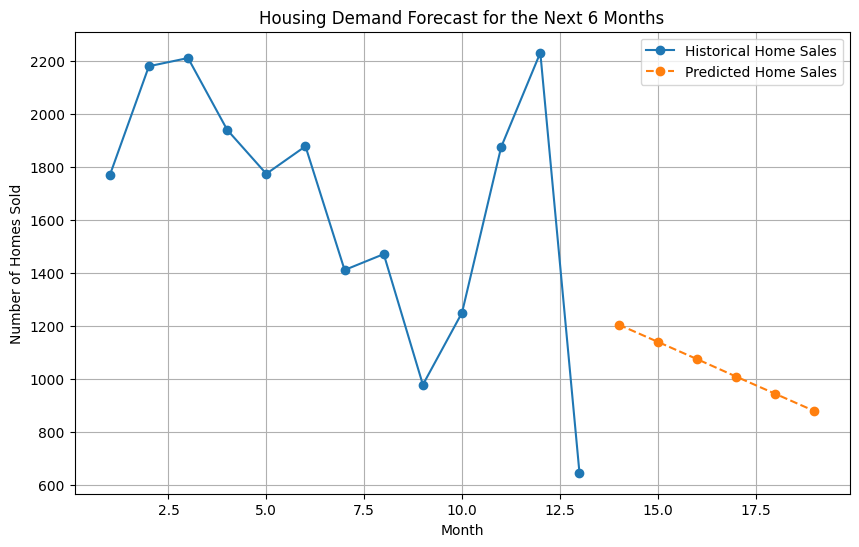

In [17]:
# Plot historical and predicted housing demand
plt.figure(figsize=(10, 6))

# Historical sales
plt.plot(
    monthly_sales['month'],
    monthly_sales['sales'],
    marker='o',
    label='Historical Home Sales'
)

# Predicted sales
plt.plot(
    future_months['month'],
    future_months['predicted_sales'],
    marker='o',
    linestyle='--',
    label='Predicted Home Sales'
)

plt.xlabel('Month')
plt.ylabel('Number of Homes Sold')
plt.title('Housing Demand Forecast for the Next 6 Months')
plt.legend()
plt.grid(True)

# Save the visualization
plt.savefig('housing_demand_forecast.png')

plt.show()

## Assumptions, Challenges, and Potential Improvements

### Assumptions
- Monthly housing demand is represented by the number of homes sold each month.
- Historical home sales are used to identify an overall trend that can be used to forecast future demand.
- A Linear Regression model is used to create a simple six-month forecast.

### Challenges
- The dataset contains only about one year of historical sales data, which limits the amount of information available for forecasting.
- The final month in the dataset appears to contain incomplete sales data, which may influence the downward trend in the forecast.
- Housing demand can change due to factors that are not included in this model, such as seasonality, interest rates, economic conditions, and changes in housing inventory.

### Potential Improvements
- Use multiple years of historical housing data to identify longer-term trends and seasonal patterns.
- Include additional factors such as housing inventory, interest rates, average home prices, and economic conditions.
- Compare Linear Regression with more advanced forecasting methods that can better account for seasonal changes in housing demand.